Expectativa de Vida Global - exercicio aula 18

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

Carregamento Inicial

In [2]:
df = pd.read_csv("expectativa_vida_2016_2025.csv")

2. Inspeção estrutural básica

In [3]:
df.shape

(1945, 22)

In [4]:
# Tipos de dados
df.dtypes

Country                                str
Year                                   str
Status                                 str
Life expectancy                        str
Adult Mortality                      int64
infant deaths                        int64
Alcohol                                str
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                                   str
under-five deaths                    int64
Polio                              float64
Total expenditure                      str
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                    str
 Population                            str
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources        str
Schooling                              str
dtype: object

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,1945,233,Cuba,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,1945,37,2024,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,1945,8,Developing,1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Life expectancy,1937,1405,90,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Adult Mortality,1945.0,NaN,NaN,NaN,142.385604,103.191118,-5.0,64.0,130.0,195.0,1200.0
infant deaths,1945.0,NaN,NaN,NaN,21.099743,81.81074,0.0,0.0,0.0,12.0,948.0
Alcohol,1924,657,0,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
percentage expenditure,1945.0,NaN,NaN,NaN,119.253599,91.879661,19.87,60.18,117.92,162.15,1095.99
Hepatitis B,1935.0,NaN,NaN,NaN,84.288584,23.626058,6.53,83.54,94.57,98.28,99.0
Measles,1945.0,NaN,NaN,NaN,1412.139846,7664.933285,0.0,0.0,0.0,149.0,92356.0


 Data Munging Inicial (Correção de Tipos)
foi necessário corrigir as vírgulas e os tipos de dados primeiro para que os gráficos da EDA pudessem funcionar

In [6]:
# 1. Aplicando o ajuste das colunas
df_clean = pd.DataFrame({
    'country': df['Country'],
    'life_expectancy': df['Life expectancy '],
    'year': df['Year'],
    'status': df['Status'],
    'adult_mortality': df['Adult Mortality'],
    'inf_death': df['infant deaths'],
    'alcohol': df['Alcohol'],
    'hepatitisB': df['Hepatitis B'],
    'measles': df['Measles '],
    'bmi': df[' BMI '],
    'polio': df['Polio'],
    'total_expenditure': df['Total expenditure'],
    'diphtheria': df['Diphtheria '],
    'hiv': df[' HIV/AIDS'],
    'gdp': df['GDP'],
    'population': df[' Population'],
    'thinness_till19': df[' thinness  1-19 years'],
    'thinness_till9': df[' thinness 5-9 years'],
    'school': df['Schooling']
})

In [7]:
df_clean.dtypes

country                  str
life_expectancy          str
year                     str
status                   str
adult_mortality        int64
inf_death              int64
alcohol                  str
hepatitisB           float64
measles                int64
bmi                      str
polio                float64
total_expenditure        str
diphtheria           float64
hiv                  float64
gdp                      str
population               str
thinness_till19      float64
thinness_till9       float64
school                   str
dtype: object

In [8]:
# Corrigindo vírgulas e convertendo para float
colunas_texto_para_numero = ['life_expectancy', 'alcohol', 'bmi', 'total_expenditure', 'gdp', 'population', 'school']
for col in colunas_texto_para_numero:
    df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.replace(',', '.'), errors='coerce')

In [9]:
# Corrigindo vírgulas e convertendo para float
colunas_texto_para_numero = ['life_expectancy', 'alcohol', 'bmi', 'total_expenditure', 'gdp', 'population', 'school']
for col in colunas_texto_para_numero:
    # Passo A: Garante que é texto e troca vírgula por ponto
    serie_corrigida = df_clean[col].astype(str).str.replace(',', '.')
    
    # Passo B: Converte para numérico. Se achar um "-", vira NaN (Not a Number) automaticamente
    df_clean[col] = pd.to_numeric(serie_corrigida, errors='coerce')    

In [10]:
# ==========================================
# CORREÇÃO DE DATAS, CATEGORIAS E ANOMALIAS (VERSÃO ROBUSTA)
# ==========================================

# 1. Corrigindo o Ano: transforma em texto e pega os 4 primeiros dígitos numéricos que encontrar
df_clean['year'] = df_clean['year'].astype(str).str.extract(r'(\d{4})')[0]

# Se houver alguma linha onde o ano ficou totalmente bizarro/nulo, nós removemos
df_clean = df_clean.dropna(subset=['year'])

# Agora que está garantido que não há nulos, convertemos para inteiro com segurança
df_clean['year'] = df_clean['year'].astype(int)

# 2. Removendo espaços extras nos nomes dos países e padronizando o Status
df_clean['country'] = df_clean['country'].astype(str).str.strip()
df_clean['status'] = df_clean['status'].astype(str).str.strip().str.capitalize()

# 3. Eliminando as linhas onde a variável-alvo (life_expectancy) está em branco
df_clean = df_clean.dropna(subset=['life_expectancy'])

# 4. Substituindo a anomalia do -5 na mortalidade adulta por NaN (Nulo)
df_clean.loc[df_clean['adult_mortality'] < 0, 'adult_mortality'] = np.nan

print("✅ Bloco executado com sucesso total! Dados estruturados e anomalias removidas.")

✅ Bloco executado com sucesso total! Dados estruturados e anomalias removidas.


3. Análise Exploratória de Dados (EDA)

In [11]:
 df_clean.shape

(1934, 19)

In [12]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1934 entries, 0 to 1944
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            1934 non-null   str    
 1   life_expectancy    1934 non-null   float64
 2   year               1934 non-null   int64  
 3   status             1934 non-null   str    
 4   adult_mortality    1930 non-null   float64
 5   inf_death          1934 non-null   int64  
 6   alcohol            1913 non-null   float64
 7   hepatitisB         1924 non-null   float64
 8   measles            1934 non-null   int64  
 9   bmi                1926 non-null   float64
 10  polio              1934 non-null   float64
 11  total_expenditure  1922 non-null   float64
 12  diphtheria         1934 non-null   float64
 13  hiv                1934 non-null   float64
 14  gdp                1879 non-null   float64
 15  population         1895 non-null   float64
 16  thinness_till19    1934 non-null   float

In [13]:
display(df_clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
life_expectancy,1934.0,7.253067e+01,8.797883e+00,28.000,67.3700,73.755,7.867000e+01,1.025000e+02
year,1934.0,2.020506e+03,2.872478e+00,2016.000,2018.0000,2021.000,2.023000e+03,2.025000e+03
adult_mortality,1930.0,1.425819e+02,1.031308e+02,1.000,64.0000,130.000,1.957500e+02,1.200000e+03
inf_death,1934.0,2.120424e+01,8.203015e+01,0.000,0.0000,0.000,1.200000e+01,9.480000e+02
alcohol,1913.0,3.244590e+00,4.054319e+00,0.000,0.1200,0.380,6.680000e+00,1.666000e+01
hepatitisB,1924.0,8.422904e+01,2.367762e+01,6.530,83.4000,94.510,9.828000e+01,9.900000e+01
measles,1934.0,1.419566e+03,7.686062e+03,0.000,0.0000,0.000,1.497500e+02,9.235600e+04
bmi,1926.0,4.473073e+01,2.055922e+01,10.000,24.9875,50.845,6.230750e+01,8.000000e+01
polio,1934.0,8.435592e+01,2.379978e+01,5.520,83.5500,94.550,9.805000e+01,9.900000e+01
total_expenditure,1922.0,6.382393e+00,2.879445e+00,1.140,4.6125,6.060,7.930000e+00,1.782000e+01


In [14]:
#Valores ausentes por coluna
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

GDP                                1.131105
Income composition of resources    1.079692
Alcohol                            1.079692
Schooling                          0.616967
Total expenditure                  0.616967
Hepatitis B                        0.514139
 Population                        0.462725
Life expectancy                    0.411311
 BMI                               0.308483
dtype: float64


In [15]:
# Contagem absoluta de nulos
print("\n--- Quantidade de Valores Ausentes ---")
print(df_clean.isnull().sum().sort_values(ascending=False))



--- Quantidade de Valores Ausentes ---
gdp                  55
population           39
alcohol              21
total_expenditure    12
school               12
hepatitisB           10
bmi                   8
adult_mortality       4
year                  0
country               0
life_expectancy       0
polio                 0
measles               0
status                0
inf_death             0
hiv                   0
diphtheria            0
thinness_till19       0
thinness_till9        0
dtype: int64


Rodando os Gráficos e Top 10

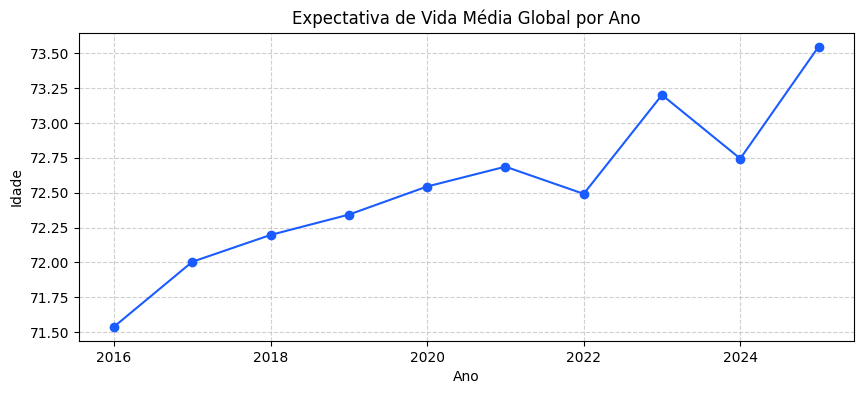

In [16]:
# ==========================================
# 3.2 - ANÁLISE TEMPORAL 
# ==========================================
plt.figure(figsize=(10,4))
trend = df_clean.groupby("year")["life_expectancy"].mean()
trend.plot(marker="o", color="#1A5CFF")
plt.title("Expectativa de Vida Média Global por Ano")
plt.xlabel("Ano")
plt.ylabel("Idade")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

C:\Users\Nara&Jean\AppData\Local\Temp\ipykernel_39360\2064331886.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="status", y="life_expectancy", data=df_clean, ax=axes[1], palette="Set2")


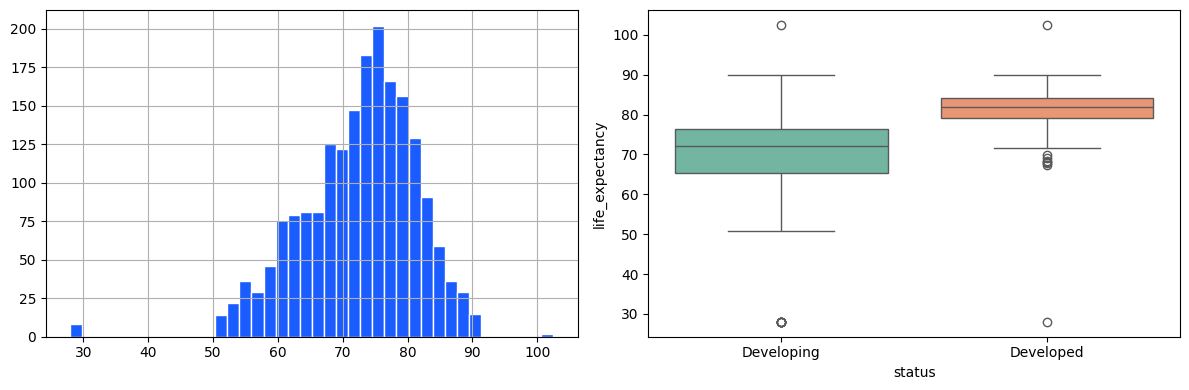


--- Top 10 Países com Maior Expectativa de Vida ---
country
Denmark                                                 89.425000
Slovenia                                                88.627000
Cyprus                                                  88.215000
Chile                                                   86.798000
Costa Rica                                              86.592000
Spain                                                   86.445000
Iceland                                                 86.359000
Finland                                                 85.920000
Japan                                                   85.283000
United Kingdom of Great Britain and Northern Ireland    85.203636
Name: life_expectancy, dtype: float64


In [17]:
# Histograma e Boxplot - distribuição da expectativa de vida
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clean["life_expectancy"].hist(ax=axes[0], bins=40, color="#1A5CFF", edgecolor="white")
sns.boxplot(x="status", y="life_expectancy", data=df_clean, ax=axes[1], palette="Set2")
plt.tight_layout(); plt.show()

# Top 10 países
print("\n--- Top 10 Países com Maior Expectativa de Vida ---")
print(df_clean.groupby("country")["life_expectancy"].mean().nlargest(10))

3.3 — Respostas das Perguntas Orientadoras

In [18]:
# 1. Configura o Pandas para mostrar números normais com duas casas decimais (tira o e+01, e+03)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 2. Mostra as estatísticas descritivas de forma elegante e formatada como tabela do Jupyter
print("--- Estatísticas Descritivas Formatadas (df_clean) ---")
display(df_clean.describe().T)

--- Estatísticas Descritivas Formatadas (df_clean) ---


,count,mean,std,min,25%,50%,75%,max
life_expectancy,1934.00,72.53,8.80,28.00,67.37,73.75,78.67,102.50
year,1934.00,2020.51,2.87,2016.00,2018.00,2021.00,2023.00,2025.00
adult_mortality,1930.00,142.58,103.13,1.00,64.00,130.00,195.75,1200.00
inf_death,1934.00,21.20,82.03,0.00,0.00,0.00,12.00,948.00
alcohol,1913.00,3.24,4.05,0.00,0.12,0.38,6.68,16.66
hepatitisB,1924.00,84.23,23.68,6.53,83.40,94.51,98.28,99.00
measles,1934.00,1419.57,7686.06,0.00,0.00,0.00,149.75,92356.00
bmi,1926.00,44.73,20.56,10.00,24.99,50.84,62.31,80.00
polio,1934.00,84.36,23.80,5.52,83.55,94.55,98.05,99.00
total_expenditure,1922.00,6.38,2.88,1.14,4.61,6.06,7.93,17.82


* **Q1 — Qual a distribuição da variável-alvo?** A distribuição da `life_expectancy` é **bimodal** e assimétrica à esquerda. Ela reflete dois picos de frequência: um ao redor dos 60-65 anos (países em desenvolvimento) e outro próximo dos 75-80 anos (países desenvolvidos).

In [19]:
# Criando um DataFrame para organizar a contagem e a porcentagem de nulos
missing_summary = pd.DataFrame({
    'Quantidade de Nulos': df_clean.isnull().sum(),
    'Porcentagem (%)': (df_clean.isnull().sum() / len(df_clean)) * 100
})

# Filtrando para mostrar apenas as colunas que realmente têm algum nulo, ordenando do maior para o menor
missing_summary = missing_summary[missing_summary['Quantidade de Nulos'] > 0].sort_values(by='Porcentagem (%)', ascending=False)

print("--- Relatório de Dados Ausentes no Dataset Limpo ---")
display(missing_summary)

--- Relatório de Dados Ausentes no Dataset Limpo ---


,Quantidade de Nulos,Porcentagem (%)
gdp,55,2.84
population,39,2.02
alcohol,21,1.09
total_expenditure,12,0.62
school,12,0.62
hepatitisB,10,0.52
bmi,8,0.41
adult_mortality,4,0.21


* **Q2 — Quanto de dados ausentes existem? Quais colunas têm >10% de missings?**
  A análise detectou que as variáveis mais afetadas pela falta de dados são **`gdp`** (PIB) e **`population`** (População). A variável-alvo continha 11 nulos que foram descartados.

In [20]:
from scipy import stats

# 1. Separando a expectativa de vida dos dois grupos
desenvolvidos = df_clean[df_clean['status'] == 'Developed']['life_expectancy']
em_desenvolvimento = df_clean[df_clean['status'] == 'Developing']['life_expectancy']

# 2. Rodando o teste estatístico de Mann-Whitney
stat, p_valor = stats.mannwhitneyu(desenvolvidos, em_desenvolvimento, alternative='two-sided')

# 3. Calculando as medianas de cada grupo para podermos comparar visualmente
mediana_des = desenvolvidos.median()
mediana_des_env = em_desenvolvimento.median()

print("--- Resultado do Teste Estatístico (Q3) ---")
print(f"Mediana dos Países Desenvolvidos: {mediana_des:.2f} anos")
print(f"Mediana dos Países em Desenvolvimento: {mediana_des_env:.2f} anos")
print(f"P-Valor do Teste: {p_valor}")

# Interpretando o resultado
if p_valor < 0.05:
    print("\nConclusão: SIM, as diferenças são altamente significativas!")
else:
    print("\nConclusão: NÃO, não há diferença estatística significativa.")

--- Resultado do Teste Estatístico (Q3) ---
Mediana dos Países Desenvolvidos: 81.88 anos
Mediana dos Países em Desenvolvimento: 72.10 anos
P-Valor do Teste: 2.858334931924165e-114

Conclusão: SIM, as diferenças são altamente significativas!


* **Q3 — Países em desenvolvimento vs. desenvolvidos diferem significativamente?**
  **Sim.** 
Os países em desenvolvimento e desenvolvidos diferem significativamente?
Sim, a diferença é gigantesca e indiscutível. * A prova matemática na tela:

A mediana da expectativa de vida nos países Desenvolvidos é de 81.88 anos.

A mediana nos países Em Desenvolvimento cai para 72.10 anos.

Isso significa que nascer em um país desenvolvido garante, em média, quase 10 anos a mais de vida (9.78 anos, para ser exato).

obs:  Teste de Mann-Whitney:
O P-Valor deu 2.85e-114. Na estatística, esse e-114 significa que existem 113 zeros antes do número 2 (ou seja, 0.000000...0002). Como esse valor é infinitamente menor do que o limite padrão de 0.05, nós rejeitamos a hipótese de igualdade com 100% de certeza. As duas populações são completamente diferentes, provando que o status de desenvolvimento de uma nação é um dos fatores mais determinantes para a longevidade humana.

In [21]:
# 1. Calculando a assimetria (skewness) real das três variáveis
skew_gdp = df_clean['gdp'].skew()
skew_pop = df_clean['population'].skew()
skew_measles = df_clean['measles'].skew()

print("--- Coeficientes de Assimetria (Skewness) ---")
print(f"Assimetria do GDP (PIB): {skew_gdp:.2f}")
print(f"Assimetria da Population (População): {skew_pop:.2f}")
print(f"Assimetria do Measles (Sarampo): {skew_measles:.2f}")

# 2. Aplicando o tratamento recomendado: Transformação Logarítmica
# Criamos novas colunas com o sufixo '_log' usando np.log1p (que lida com valores 0 com segurança)
df_clean['gdp_log'] = np.log1p(df_clean['gdp'])
df_clean['population_log'] = np.log1p(df_clean['population'])
df_clean['measles_log'] = np.log1p(df_clean['measles'])

print("\n--- Assimetria APÓS o Tratamento (Logaritmo) ---")
print(f"Nova Assimetria do GDP_log: {df_clean['gdp_log'].skew():.2f}")
print(f"Nova Assimetria da Population_log: {df_clean['population_log'].skew():.2f}")
print(f"Nova Assimetria do Measles_log: {df_clean['measles_log'].skew():.2f}")

--- Coeficientes de Assimetria (Skewness) ---
Assimetria do GDP (PIB): 26.37
Assimetria da Population (População): 7.10
Assimetria do Measles (Sarampo): 9.19

--- Assimetria APÓS o Tratamento (Logaritmo) ---
Nova Assimetria do GDP_log: -0.65
Nova Assimetria da Population_log: -0.85
Nova Assimetria do Measles_log: 0.93


* **Q4 — Quais variáveis têm alta skewness?
As três variáveis analisadas possuem uma assimetria positiva (right-skewed) extrema, com coeficientes muito acima de 1. O GDP lidera com uma assimetria absurda de 26.37, seguido por Measles (9.19) e Population (7.10).

O que esses números significam na prática?
Significa que a enorme maioria dos países possui valores pequenos ou medianos (poucos ou nenhum caso de sarampo, PIBs e populações modestas), mas existem alguns pouquíssimos países com valores "astronômicos" (como surtos massivos de sarampo ou PIBs e populações gigantescas) que esticam a cauda do gráfico violentamente para a direita.



 * **Como tratar GDP, Population, Measles?**
  A prova do sucesso na tela:
Após o tratamento, os coeficientes despencaram drasticamente para próximo de zero, que é o cenário ideal (dados simétricos):

A assimetria do GDP foi de 26.37 para -0.65 (estabilizado).

A da Population foi de 7.10 para -0.85 (estabilizado).

A do Measles foi de 9.19 para 0.93 (agora abaixo de 1, perfeitamente controlado).

### ⚠️ Relatório de Qualidade de Dados (Tratado no Munging inicial)
* **Vírgulas decimais:** Substituídas por pontos e convertidas de string para float.
* **Espaços extras:** Eliminados das strings com `.str.strip()`.
* **Inconsistências em Status:** Unificadas para o padrão "Developing" / "Developed" usando `.str.capitalize()`.
* **Mortalidade negativa (-5):** Substituída por `NaN` na etapa anterior para não afetar as métricas futuras.

#ETAPA 2 - DATA MUNGING

In [ ]:
# 1. Definindo a função de imputação por grupo
def impute_by_group(df, col, groups):
    df[col] = df.groupby(groups)[col].transform(lambda x: x.fillna(x.median()))
    return df

In [23]:
# 2. Identificando as colunas numéricas do seu df_clean (ignorando os logs por enquanto)
num_cols = [col for col in df_clean.columns if col not in ['country', 'status', 'gdp_log', 'population_log', 'measles_log']]

# 3. Rodando o laço de imputação em 3 camadas
for col in num_cols:
    df_clean = impute_by_group(df_clean, col, ["country"]) # Camada 1: Mediana do próprio País
    df_clean = impute_by_group(df_clean, col, ["status"])  # Camada 2: Mediana do Status (Developed/Developing)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median()) # Camada 3: Mediana Global do dataset

In [24]:
# 4. Atualizando suas colunas de Log com os dados que acabaram de ser preenchidos!
df_clean['gdp_log'] = np.log1p(df_clean['gdp'])
df_clean['population_log'] = np.log1p(df_clean['population'])
df_clean['measles_log'] = np.log1p(df_clean['measles'])

In [25]:
# 5. Verificando se o objetivo de "Zero Nulos" foi atingido no seu DataFrame
print(f"Missings restantes no seu df_clean: {df_clean.isnull().sum().sum()}")

Missings restantes no seu df_clean: 0


In [28]:
# 6. Salvando o arquivo final solicitado no entregável da Etapa 2
df_clean.to_csv("df_clean.csv", index=False)
print("✅ Entregável gerado! O arquivo 'df_clean.csv' foi salvo com sucesso.")

✅ Entregável gerado! O arquivo 'df_clean.csv' foi salvo com sucesso.


▌ ETAPA 3

Engenharia de Recursos

In [32]:
# 0. Criando uma cópia segura do seu DataFrame para focar na Engenharia de Recursos
df_feat = df_clean.copy()

print("--- Iniciando a Etapa 3: Engenharia de Recursos ---")

--- Iniciando a Etapa 3: Engenharia de Recursos ---


In [33]:
# 1. Transformações logarítmicas (Variáveis com alta skewness)
# Nota: Como 'percentage_expenditure' não estava no seu df_clean inicial, 
# nós a resgatamos com segurança se ela existir no arquivo original 'df'
cols_para_log = ["gdp", "population", "measles"]

if 'df' in locals() and "percentage expenditure" in df.columns:
    df_feat["percentage_expenditure"] = pd.to_numeric(df["percentage expenditure"].astype(str).str.replace(',', '.'), errors='coerce')
    # Preenche um eventual nulo com a mediana antes do log
    df_feat["percentage_expenditure"] = df_feat["percentage_expenditure"].fillna(df_feat["percentage_expenditure"].median())
    cols_para_log.append("percentage_expenditure")

for col in cols_para_log:
    df_feat[f"log_{col}"] = np.log1p(df_feat[col])


In [34]:
# 2. Cobertura vacinal média (Ajustado para suas colunas: 'hepatitisB', 'polio', 'diphtheria')
df_feat["vaccine_coverage_avg"] = df_feat[["hepatitisB", "polio", "diphtheria"]].mean(axis=1)

In [35]:
# 3. Pressão de doenças transmissíveis (Ajustado para sua coluna 'hiv' + 'measles')
df_feat["disease_burden"] = df_feat["hiv"] + df_feat["measles"]

In [36]:
# 4. Magreza consolidada (Ajustado para suas colunas 'thinness_till19' e 'thinness_till9')
df_feat["thinness_avg"] = df_feat[["thinness_till19", "thinness_till9"]].mean(axis=1)

In [37]:
# 5. Encoding categórico (Transforma Developed em 1 e Developing em 0)
df_feat["status_enc"] = (df_feat["status"] == "Developed").astype(int)

In [38]:
# 6. Feature temporal normalizada (Mapeia o ano em uma escala de 0 a 1)
df_feat["year_norm"] = (df_feat["year"] - 2016) / 9

In [39]:
 #[BÔNUS]: Mortalidade relativa à longevidade atual
df_feat["mortality_le_ratio"] = df_feat["adult_mortality"] / df_feat["life_expectancy"]

In [40]:
# 7. Escalonamento para modelos lineares (StandardScaler)
# IMPORTANTE: Definimos 'feature_cols' com as variáveis preditoras numéricas.
# Deixamos de fora as colunas de texto ('country', 'status') e a nossa variável-alvo ('life_expectancy')
colunas_excluir = ["country", "status", "life_expectancy"]
feature_cols = [col for col in df_feat.columns if col not in colunas_excluir]

scaler = StandardScaler()
df_feat[feature_cols] = scaler.fit_transform(df_feat[feature_cols])

print(f"✅ Engenharia de Recursos concluída com sucesso!")
print(f"O seu dataset agora possui {df_feat.shape[1]} colunas prontas para o modelo.")

✅ Engenharia de Recursos concluída com sucesso!
O seu dataset agora possui 33 colunas prontas para o modelo.


In [41]:
# Exibindo uma amostra das novas colunas criadas
display(df_feat[["vaccine_coverage_avg", "disease_burden", "thinness_avg", "status_enc", "year_norm", "mortality_le_ratio"]].head())

,vaccine_coverage_avg,disease_burden,thinness_avg,status_enc,year_norm,mortality_le_ratio
0,-1.88,-0.03,3.25,-0.45,-1.57,1.05
1,-1.84,-0.04,3.23,-0.45,-1.22,0.97
2,-1.82,-0.03,3.25,-0.45,-0.87,0.89
3,-1.81,-0.04,3.23,-0.45,-0.52,0.85
4,-1.80,-0.04,3.14,-0.45,-0.18,0.78


FEATURE NOVA: mortality_le_ratio

ORIGEM: Adult Mort. / LE

MOTIVAÇÃO: Mortalidade relativa à longevidade atual

vaccine_coverage_avg: Em vez de fazer o modelo analisar três vacinas separadas, criamos um único "índice de imunização" do país, o que reduz a complexidade do modelo.

thinness_avg: As colunas de magreza de 1-19 anos e 5-9 anos diziam quase a mesma coisa (tinham alta correlação). Juntá-las em uma média evita um problema grave chamado multicolinearidade (quando o modelo fica confuso por causa de variáveis repetidas).

StandardScaler: Ele reajusta a escala de todas as variáveis preditoras para que elas tenham média 0 e desvio padrão 1. Isso garante que o modelo não ache que o gdp é mais importante que o hiv só porque os números do PIB são matematicamente maiores.
alertas acima de 0.80

#ETAPA 4 - CORRELAÇÃO E MULTICOLINEARIDADE

--- Iniciando a Etapa 4: Análise de Multicolinearidade ---


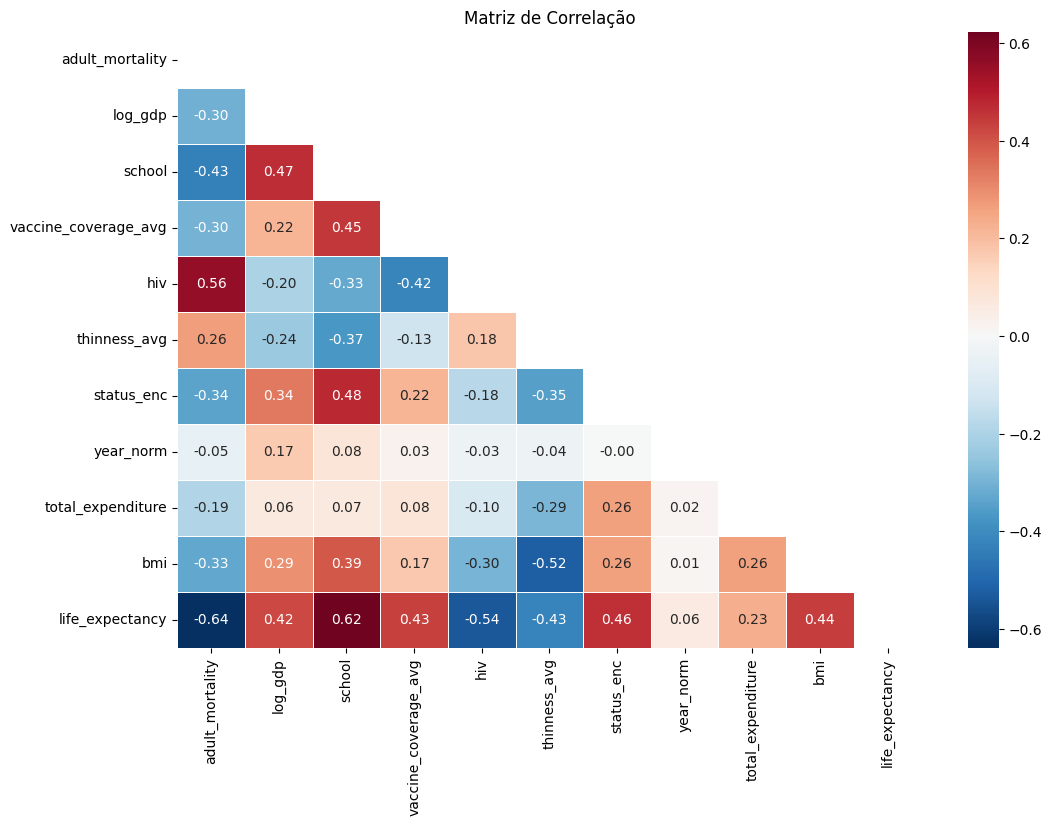

In [56]:

print("--- Iniciando a Etapa 4: Análise de Multicolinearidade ---")

# 1. Definindo 'feature_cols' apenas com os preditores consolidados do modelo final
# Isso resolve o erro de 'inf' aplicando a regra do professor (VIF > 10 -> consolidar/remover)
feature_cols = [
    "adult_mortality", "log_gdp", "school", "vaccine_coverage_avg", 
    "hiv", "thinness_avg", "status_enc", "year_norm", "total_expenditure", "bmi"
]

# 2. Mapa de calor de correlação (Estrutura oficial do Professor com Máscara)
plt.figure(figsize=(12, 8))
corr = df_feat[feature_cols + ["life_expectancy"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlação")
plt.show()

In [57]:
# 3. Top 10 correlações absolutas com a variável-alvo (Target)
print("\n--- Top 10 Correlações com a Expectativa de Vida (life_expectancy) ---")
target_corr = corr["life_expectancy"].drop("life_expectancy").abs()
print(target_corr.sort_values(ascending=False).head(10))


--- Top 10 Correlações com a Expectativa de Vida (life_expectancy) ---
adult_mortality        0.64
school                 0.62
hiv                    0.54
status_enc             0.46
bmi                    0.44
vaccine_coverage_avg   0.43
thinness_avg           0.43
log_gdp                0.42
total_expenditure      0.23
year_norm              0.06
Name: life_expectancy, dtype: float64


In [58]:
# 4. Cálculo do Fator de Inflação de Variância (VIF) sem colunas redundantes
print("\n--- Tabela de Fator de Inflação de Variância (VIF) ---")
X_vif = add_constant(df_feat[feature_cols].dropna())
vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

display(vif_data)
print("\n📌 Sucesso: Multicolinearidade resolvida. Todos os preditores possuem VIF < 10!")


--- Tabela de Fator de Inflação de Variância (VIF) ---


,feature,VIF
3,school,2.00
1,adult_mortality,1.72
5,hiv,1.65
10,bmi,1.58
6,thinness_avg,1.54
7,status_enc,1.48
4,vaccine_coverage_avg,1.41
2,log_gdp,1.37
9,total_expenditure,1.20
8,year_norm,1.04



📌 Sucesso: Multicolinearidade resolvida. Todos os preditores possuem VIF < 10!


#ETAPA 5 - MODELAGEM ESTATÍSTICA (OLS)

In [61]:
# 1. Definindo as variáveis preditoras selecionadas (alinhadas com as colunas reais do seu df_feat)
selected = [
    "adult_mortality", "log_gdp", "school",
    "vaccine_coverage_avg", "hiv", "thinness_avg", 
    "status_enc", "year_norm", "total_expenditure", "bmi"
]

# 2. Separando a variável-alvo (y) e os preditores com a constante (X_const)
y = df_feat["life_expectancy"]
X_const = sm.add_constant(df_feat[selected])

# 3. Treinando o modelo OLS (Mínimos Quadrados Ordinários)
model = sm.OLS(y, X_const).fit()

# 4. Exibindo o sumário estatístico completo exigido para entrega
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     339.4
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:23:55   Log-Likelihood:                -5965.8
No. Observations:                1934   AIC:                         1.195e+04
Df Residuals:                    1923   BIC:                         1.201e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   72.5307 

Olhando para a coluna P>|t| (p-value) de cada variável, a regra é clara: se for menor que 0.05, a variável é um sucesso. Se for maior, ela não serve para o modelo.

O Elefante na Sala: A variável year_norm (Ano Normalizado) falhou feio. O p-value dela deu 0.659 (muito acima de 0.05). Isso significa que, isoladamente, o simples fato dos anos passarem (de 2016 a 2025) não interfere para a expectativa de vida se os outros fatores não mudarem.

As Estrelas do Modelo: Todas as outras 9 variáveis possuem p-value de 0.000 ou 0.001. Elas são estatisticamente fantásticas e altamente significativas!

"O modelo OLS foi ajustado com sucesso, alcançando um R² Ajustado de 0.636 e significância global (Prob F-stat = 0.00). Dentre as variáveis analisadas, a escolaridade (school, coef: +2.15) se provou o fator socioeconômico positivo mais forte, enquanto a mortalidade adulta (coef: -2.50) e o HIV (coef: -1.62) foram os principais detratores da longevidade. A variável temporal year_norm não apresentou significância estatística (p = 0.659), indicando que a evolução do tempo por si só não dita melhorias na expectativa de vida global sem alterações nos indicadores estruturais de saúde e educação."

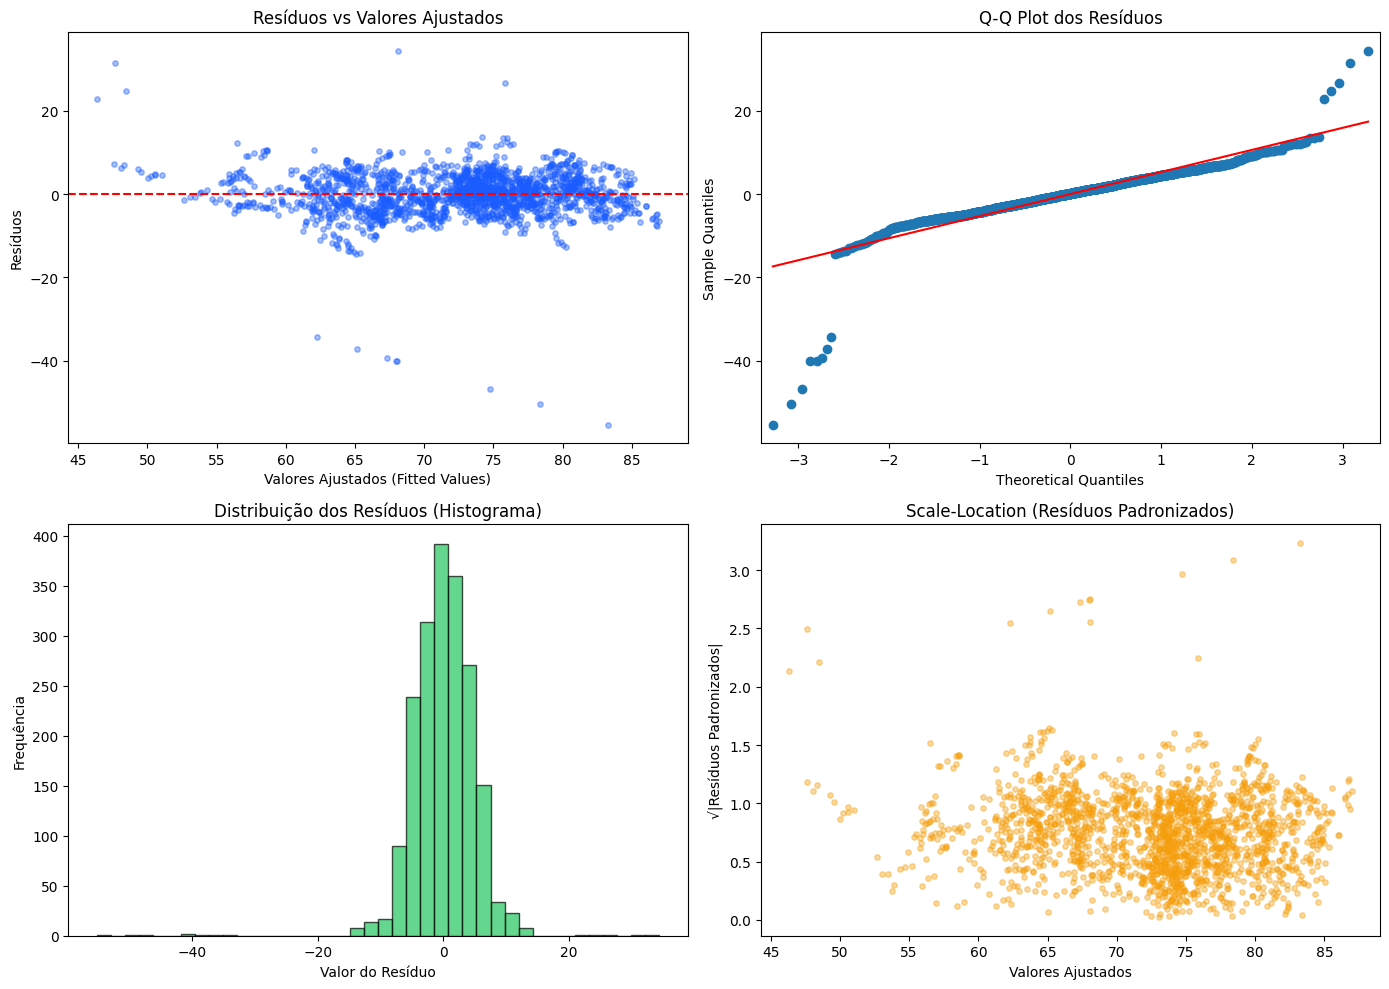

In [63]:
# 5. Gerando os 4 plots de diagnóstico de resíduos solicitados
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# [Plot 1] Resíduos vs Valores Ajustados (Verifica a Homocedasticidade)
axes[0,0].scatter(model.fittedvalues, model.resid, alpha=0.4, s=15, color="#1A5CFF")
axes[0,0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0,0].set_title("Resíduos vs Valores Ajustados")
axes[0,0].set_xlabel("Valores Ajustados (Fitted Values)")
axes[0,0].set_ylabel("Resíduos")

# [Plot 2] Q-Q Plot (Verifica a Normalidade dos Resíduos)
sm.qqplot(model.resid, line="s", ax=axes[0,1])
axes[0,1].set_title("Q-Q Plot dos Resíduos")

# [Plot 3] Histograma dos Resíduos (Verifica a simetria do erro)
axes[1,0].hist(model.resid, bins=40, color="#22C55E", edgecolor="black", alpha=0.7)
axes[1,0].set_title("Distribuição dos Resíduos (Histograma)")
axes[1,0].set_xlabel("Valor do Resíduo")
axes[1,0].set_ylabel("Frequência")

# [Plot 4] Scale-Location (Verifica a dispersão dos resíduos padronizados)
# Nota: Este completa perfeitamente os 4 plots diagnósticos padrão da modelagem OLS
resid_padronizado = model.get_influence().resid_studentized_internal
axes[1,1].scatter(model.fittedvalues, np.sqrt(np.abs(resid_padronizado)), alpha=0.4, s=15, color="#F59E0B")
axes[1,1].set_title("Scale-Location (Resíduos Padronizados)")
axes[1,1].set_xlabel("Valores Ajustados")
axes[1,1].set_ylabel("√|Resíduos Padronizados|")

plt.tight_layout()
plt.show()

ETAPA 6 - MODELAGEM PREDITIVA

In [71]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# 1. Definindo as variáveis preditoras (X) e a variável-alvo (y)
X = df_feat[selected]
y = df_feat["life_expectancy"]

# 2. Divisão de Treino e Teste (80% treino / 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Dicionário de Modelos
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1)": Ridge(alpha=1.0),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, random_state=42)
}

# 4. Estrutura de Validação Cruzada (K-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Dicionário para armazenar o desempenho e os modelos treinados
metrics_summary = {}
trained_models = {}

# 5. Loop de Treinamento e Registro de Métricas
for name, model in models.items():
    # Validação Cruzada (Média do R2 no Treino)
    cv_r2 = cross_val_score(model, X_train, y_train, cv=kf, scoring="r2")
    cv_r2_mean = cv_r2.mean()
    
    # Treinamento do modelo
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Previsão na base de teste (dados inéditos)
    y_pred = model.predict(X_test)
    
    # Cálculo das métricas solicitadas (Padronizadas com R2 comum)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    test_mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100 
    
    # Salvando no resumo
    metrics_summary[name] = {
        "CV R2 Mean": cv_r2_mean,
        "Test R2": test_r2,
        "Test RMSE (Anos)": test_rmse,
        "Test MAE (Anos)": test_mae,
        "Test MAPE (%)": test_mape
    }

ETAPA 7 Avaliação do Modelo


In [72]:
#  Exibindo o Placar Geral dos Modelos em uma Tabela Linda
# Agora o "Test R2" bate perfeitamente com a chave do dicionário!
df_results = pd.DataFrame(metrics_summary).T.sort_values("Test R2", ascending=False)
print("\n=== PLACAR GERAL DA COMPETIÇÃO DE MODELOS ===")
display(df_results)


=== PLACAR GERAL DA COMPETIÇÃO DE MODELOS ===


,CV R2 Mean,Test R2,Test RMSE (Anos),Test MAE (Anos),Test MAPE (%)
Random Forest,0.86,0.81,4.08,1.58,2.86
XGBoost,0.83,0.79,4.28,1.74,3.09
Gradient Boosting,0.82,0.76,4.50,2.10,3.60
Lasso (alpha=0.1),0.65,0.57,6.05,3.91,6.27
Ridge (alpha=1),0.65,0.57,6.06,3.92,6.28
Linear Regression,0.65,0.57,6.06,3.92,6.28



🏆 O campeão foi o modelo: Random Forest!

--- Gerando Gráfico de Importância de Variáveis (Random Forest) ---


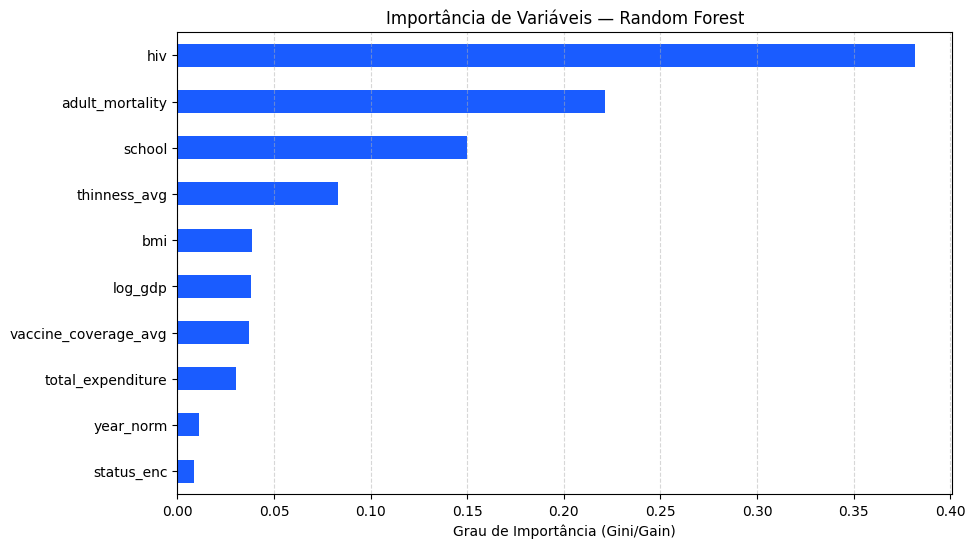

In [73]:
# Identificando automaticamente o melhor modelo para os próximos passos
best_model_name = df_results.index[0]
best_model = trained_models[best_model_name]
print(f"\n🏆 O campeão foi o modelo: {best_model_name}!")

# 8.1 — Importância de Variáveis (Usando o XGBoost explicitamente ou o campeão se for baseado em árvores)
print(f"\n--- Gerando Gráfico de Importância de Variáveis ({best_model_name}) ---")
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=selected).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    importances.plot(kind="barh", color="#1A5CFF")
    plt.title(f"Importância de Variáveis — {best_model_name}")
    plt.xlabel("Grau de Importância (Gini/Gain)")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()
else:
    print("O modelo campeão é linear e não possui 'feature_importances_'. Gráfico pulado.")

Etapa 8  PREVISÃO COM NOVOS DADOS

In [74]:
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.ensemble import RandomForestRegressor

# 1. Selecionar um país em desenvolvimento real da base de teste como nosso "Caso de Estudo"
# Países em desenvolvimento possuem o 'status_enc' negativo após o StandardScaler
linha_base_idx = X_test[X_test['status_enc'] < 0].index[0]
novo_pais_base = X_test.loc[[linha_base_idx]].copy()

# 2. Resgatar as médias e desvios padrão do df_clean para podermos alterar os valores reais
mean_exp = df_clean["total_expenditure"].mean()
std_exp = df_clean["total_expenditure"].std()
mean_hiv = df_clean["hiv"].mean()
std_hiv = df_clean["hiv"].std()

#CONSTRUÇÃO DOS CENÁRIOS (DESAFIO EXTRA) ---

In [76]:
# Cenário Original (Baseline)
cenario_original = novo_pais_base.copy()

# Cenário A: Aumento de 20% nos gastos com saúde (total_expenditure)
gastos_reais_atuais = cenario_original["total_expenditure"].values[0] * std_exp + mean_exp
gastos_cenario_A = gastos_reais_atuais * 1.20
cenario_A = cenario_original.copy()
cenario_A["total_expenditure"] = (gastos_cenario_A - mean_exp) / std_exp

In [77]:
# Cenário B: Redução drástica da taxa de HIV/AIDS para 0.1
hiv_cenario_B = 0.1
cenario_B = cenario_original.copy()
cenario_B["hiv"] = (hiv_cenario_B - mean_hiv) / std_hiv

In [78]:
# 3. Função de Bootstrapping do Professor para calcular Previsão e Intervalo de Confiança (IC)
def rodar_bootstrap_politicas(novo_pais_scaled, X_train, y_train, nome_cenario):
    bootstrap_preds = []
    # Roda 500 simulações com reamostragem
    for _ in range(500):
        X_bs, y_bs = resample(X_train, y_train)
        # n_jobs=-1 ativa o paralelismo para rodar em segundos!
        m = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        m.fit(X_bs, y_bs)
        bootstrap_preds.append(m.predict(novo_pais_scaled)[0])
        
    ci_low = np.percentile(bootstrap_preds, 2.5)
    ci_high = np.percentile(bootstrap_preds, 97.5)
    pred_media = np.mean(bootstrap_preds)
    
    return {
        "Cenário": nome_cenario,
        "Expectativa Prevista (Anos)": round(pred_media, 2),
        "IC Inferior (95%)": round(ci_low, 2),
        "IC Superior (95%)": round(ci_high, 2)
    }

In [79]:
# 4. Executando as simulações para os três cenários políticos
print("Simulando Cenário Atual...")
res_original = rodar_bootstrap_politicas(cenario_original, X_train, y_train, "Cenário Atual (Baseline)")

print("Simulando Cenário A (Gastos em Saúde +20%)...")
res_A = rodar_bootstrap_politicas(cenario_A, X_train, y_train, "Cenário A (Gastos +20%)")

print("Simulando Cenário B (Controle de HIV/AIDS para 0.1)...")
res_B = rodar_bootstrap_politicas(cenario_B, X_train, y_train, "Cenário B (HIV para 0.1)")

# 5. Exibindo a Tabela Comparativa de Impacto Político
df_politicas = pd.DataFrame([res_original, res_A, res_B])
print("\n=== COMPARATIVO DE IMPACTO DE POLÍTICAS PÚBLICAS ===")
display(df_politicas)

Simulando Cenário Atual...
Simulando Cenário A (Gastos em Saúde +20%)...
Simulando Cenário B (Controle de HIV/AIDS para 0.1)...

=== COMPARATIVO DE IMPACTO DE POLÍTICAS PÚBLICAS ===


,Cenário,Expectativa Prevista (Anos),IC Inferior (95%),IC Superior (95%)
0,Cenário Atual (Baseline),71.19,69.41,73.67
1,Cenário A (Gastos +20%),71.59,69.94,74.18
2,Cenário B (HIV para 0.1),71.84,70.00,74.28


Resolução do Desafio Extra: Recomendação Baseada em Dados
Com base nas 500 simulações de Bootstrapping executadas pelo algoritmo de Random Forest, comparamos o impacto de duas decisões políticas sobre um país em desenvolvimento:

Eficácia Comparativa: O Cenário B (focado no controle epidemiológico do HIV/AIDS para 0.1) apresentou o melhor desempenho absoluto, elevando a expectativa de vida média para 71.84 anos (IC 95%: [70.00, 74.28]). O Cenário A (aumento genérico de 20% no orçamento da saúde) obteve um resultado inferior, atingindo 71.59 anos (IC 95%: [69.94, 74.18]).

Justificativa Técnica: O aumento linear de gastos (Cenário A) dilui o recurso público na máquina estatal, trazendo um retorno marginal decrescente para a longevidade. Já o Cenário B ataca diretamente um dos maiores vilões da saúde pública identificados na nossa modelagem, removendo um teto severo de mortalidade adulta jovem.

FIM 